# Exercise 5

This exercise is based on Chapter 3 (Spatial Data) of the Geographic Data Science book.

The material can be found in: `GSP538/gds_book/notebooks/03_spatial_data.ipynb`

#### Notes on Textbook

- This chapter is largely about a different way of conceptualizing the GIS concepts you learned in GSP 531 and other courses. It is important to remember that ArcGIS Pro is not a synonym for "GIS" and that `arcpy` is not the only GIS Python package. High-level GIS and remote sensing concepts are agnostic of the software being used. Furthermore, ArcGIS Pro and Python are two of the most popular tools for working with spatial data, but there are many more (e.g., R, QGIS, Maptitude, PostgreSQL, MySQL, Google Earth Engine, etc., etc.).
- The textbook is itself built from a Jupyter notebook. This means that you need to run the cells to get the full experience. 
- If some of the cells don't run, double check that you are using the `gsp538` environment
- VS Code allows you to have side-by-side notebooks (e.g., this exercise and the book chapter).
  - Collapse the Explorer by clicking the little icon in the upper-left of VS Code
  - Click and drag the tab of the notebook you want to reposition (e.g. drag it to the right side of the VS Code window)
- Remember that the chapter is an interactive Jupyter notebook. If something is confusing or you have a question, you can insert a new cell and run your own code to see what happens.
- You have already seen that a single Python command can sometimes get quite long. The authors of this book use a consistent formatting style called [Black](https://black.readthedocs.io/en/stable/). The name refers to Henry Ford's statement that the customer can get the Model T in "any color that he wants so long as it's black." If you find the line breaks difficult to follow, feel free to edit the code cells to make them more readable for yourself.
- The `query` method of a GeoDataFrame is used here. This also exists for Pandas DataFrames. It is similar to the `loc` method you have been using so far in the course. [This article demonstrates the concept in detail.](https://medium.com/@heyamit10/understanding-pandas-dataframe-query-145a66160304) As an example, the following two lines return the same thing.
  - `my_data.loc[my_data.county == "Maricopa"]`
  - `my_data.query('county == "Maricopa"')`
- We have not worked much with Pandas Series objects so far. A DataFrame has two dimensions, i.e., rows and columns. A Series has one dimension. You can think of a Series as one column or one row of a DataFrame.
- In the "Pixels to Polygons" section, the authors demonstrate a DIY approach to computing zonal statistics. The Python code in this section is a little complicated and it is not necessary to fully understand it. Toward the end of the section, they show a one-line approach using the `zonal_stats` function from the `rasterstats` package, which is more straightforward. 

#### Answer the following written questions

There is a blank Markdown cell after each question for your answer (double click in the blank cell to type your answer). Be sure to run your Markdown cells to format your answers.

1. The authors talk about "abstraction" in terms of the objects we work with in Python relative to the myriad file types on the hard drive. Does ArcGIS Pro work similarly? Explain.

Yes, ArcGIS Pro works similarly. ArcGIS Pro can read many different file formats — shapefiles, geodatabases, GeoPackages, GeoTIFFs, CSVs, etc. — but once the data is loaded, the user works with a common set of abstractions (feature classes, raster datasets, tables) regardless of the source format. The user interacts with layers on a map and rows/columns in an attribute table, not with the raw bytes of the underlying file. Just as Python libraries read diverse formats into standard data structures like `GeoDataFrame` or `DataArray`, ArcGIS Pro abstracts away file format differences so the analyst can focus on the data itself rather than format-specific quirks.

2. This book follows the data science convention for the terms "feature" and "sample." How does this book use these terms? How is the data science use of the term "feature" different from how it is used in ArcGIS Pro?

In this book's data science convention, a **feature** is a measured characteristic or variable — a column in a table. A **sample** is one set of measurements — a row in a table. In ArcGIS Pro, however, a "feature" refers to an individual geographic entity on a map (e.g., one polygon, one point) — which corresponds to a *row*, not a column. In ArcGIS, the columns are called "attributes" or "fields." So the data science and GIS communities use the word "feature" to mean opposite things: a column in data science vs. a row/entity in GIS.

3. Why can point datasets be easily stored as CSV files, but CSV format is very difficult for line and polygon datasets?

A point is defined by just two numbers (an x-coordinate and a y-coordinate), so each point can be stored as two columns in a CSV row. Lines and polygons, however, are defined by variable-length sequences of coordinate pairs — a polygon might have dozens or hundreds of vertices, and polygons can also have holes (interior rings). There is no clean way to fit an arbitrarily long, structured list of coordinates into a flat CSV column. While you could technically encode geometry as a text string (e.g., WKT), the result is unwieldy, inefficient, and not natively supported by most CSV tools. Dedicated spatial formats like GeoPackage or Shapefile are designed to handle these complex geometries.

4. What do the rows and columns represent in geographic tables? What do rows and columns represent if we think of surface data as a table?

In a **geographic table** (GeoDataFrame), each row represents one geographic object or sample (e.g., a country, a census tract, a fire location), and each column represents a feature or attribute (e.g., name, population, geometry). The geographic location is confined to a single geometry column.

In a **surface/raster** viewed as a table, the rows and columns of the grid are directly tied to geographic locations — each row is a horizontal strip of pixels at a particular latitude, and each column is a vertical strip at a particular longitude. Each cell holds a measured value (e.g., elevation, population count) at that specific location. Unlike geographic tables, *both* dimensions carry spatial meaning rather than just a single column.

5. What do the `-200` values represent in the Sao Paulo dataset?

The `-200` values represent **NoData** (missing data). Raster formats traditionally do not have a built-in null or `NaN` concept the way tabular formats do. Instead, an impossible value is designated as the NoData sentinel. In this case, a population count of −200 is clearly impossible, so it is used to indicate cells where no population data was collected or the area falls outside the region of interest. The raster's `nodatavals` attribute records this convention so software knows to treat those cells as missing.

6. List a couple of "pros" and a couple of "cons" of treating surface data as a traditional table where rows represent samples.

**Pros:**
- When spatial location is not needed for the analysis (e.g., computing descriptive statistics), the tabular format works perfectly well and keeps things simple.
- By converting surface data to a standard tabular structure, you can leverage the vast ecosystem of tabular tools — Pandas, scikit-learn, big-data frameworks — that are well-tested and widely available.

**Cons:**
- Converting to a table means losing the inherent spatial structure (the relationship between neighboring pixels), or having to reconstruct it manually with auxiliary objects like spatial graphs.
- Operations on tabular data are generally less efficient than purpose-built raster algorithms that exploit the grid structure.
- Treating each pixel as an independent observation ignores the spatial continuity of the underlying process, which can be both computationally wasteful and statistically inappropriate.

7. What does the `geopandas.points_from_xy` function do? Why do you need to pass in a value to the `crs` parameter if you want to do any spatial analysis with the resulting object? Why did the authors pass in `4326` in the example in the textbook (hint: `4326` might be the most commonly used CRS value)?

The `geopandas.points_from_xy` function takes separate arrays of x-coordinates (longitudes) and y-coordinates (latitudes) and converts each pair into a Shapely `Point` geometry object. The result is a GeoSeries of point geometries that can be used to create a GeoDataFrame.

You need to pass a value to the `crs` parameter because raw coordinates are meaningless without knowing what coordinate reference system they belong to. Without a CRS, GeoPandas cannot perform spatial operations like distance calculations, reprojections, or overlays — it wouldn't know whether the numbers represent degrees, meters, or something else.

The authors passed in `4326` because EPSG:4326 is the **WGS 84** geographic coordinate system — the standard latitude/longitude system used by GPS and most web mapping services. It is arguably the most commonly used CRS in the world, and when coordinates are expressed as longitude/latitude in degrees, they almost always refer to WGS 84.

8. Explain at a high level what the `row2cell` function from the textbook is doing? Then explain what the lines of Python code are doing.

**High level:** The `row2cell` function takes a single row from a pixel table (where each row has the x,y center coordinates of a raster pixel) and the raster's resolution, and builds a square polygon representing that pixel's geographic footprint. This is useful for converting raster cells into vector polygons.

**Line by line:**
```python
def row2cell(row, res_xy):
    res_x, res_y = res_xy          # Unpack the resolution tuple (e.g., (250, -250) for 250m cells)
    minX = row["x"] - (res_x / 2)  # Left edge: half a pixel width left of center
    maxX = row["x"] + (res_x / 2)  # Right edge: half a pixel width right of center
    minY = row["y"] + (res_y / 2)  # Bottom edge: res_y is negative, so adding half moves downward
    maxY = row["y"] - (res_y / 2)  # Top edge: subtracting a negative moves upward
    poly = geometry.box(minX, minY, maxX, maxY)  # Create a rectangular Shapely polygon from bounding box
    return poly                     # Return the polygon
```
The key subtlety is that `res_y` is typically negative (raster convention where y decreases downward), which is why `minY` uses addition and `maxY` uses subtraction.

9. In the zonal statistics example using the rasterstats package, you will see this bit of code: `sd_tracts.to_crs(dem.rio.crs)`. What is this bit of code doing to `sd_tracts`? Why is it necessary to do this in order to compute zonal statistics between the vector layer and raster layer? (Hint: The first question is asking you to look up how this code works; the second question is related to your knowledge of GIS. Hint: `sd_tracts` is a GeoDataFrame and `dem` as a DataArray.)

`sd_tracts.to_crs(dem.rio.crs)` reprojects the `sd_tracts` GeoDataFrame from its current coordinate reference system into the same CRS as the DEM raster. `dem.rio.crs` retrieves the CRS of the raster via rioxarray, and `to_crs()` transforms all the polygon geometries accordingly.

This is necessary because computing zonal statistics requires the vector zones and the raster surface to be in the **same coordinate reference system**. If they are in different CRSs, the polygon boundaries would not align correctly with the raster grid — the spatial overlay would produce incorrect or meaningless results. This is a fundamental principle in GIS: spatial operations between layers require matching coordinate systems.

#### The following questions require you to run Python code.

The cell below imports a GeoPackage. This is standard spatial file type readable by Esri products, GeoPandas and other spatial tools. A couple things to note.
- The first two lines of code filter out warning messages from packages. "Warning messages are typically issued in situations where it is useful to alert the user of some condition in a program, where that condition (normally) doesn't warrant raising an exception and terminating the program." In general, I would not recommend suppressing warnings, but it makes things cleaner for a homework exercise.
- Just like `pd` is the common alias for `pandas`, `gpd` is the common alias for `geopandas`.

Some of the questions below ask you to use the datasets used in the textbook. The last line in the cell below reads in the data for the first question. You can follow this template for reading in the other textbook datasets.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import geopandas as gpd

countries = gpd.read_file("../gds_book/data/countries/countries_clean.gpkg")

10. One way to convert from `Multi-`type geometries into many individual geometries is using the `explode()` method of a GeoDataFrame. 
    - Using the `explode()` method, find out how many islands are in Indonesia. Code need to return a single integer. 
    - State your answer in a sentence in a Markdown cell.

In [2]:
indonesia = countries.loc[countries['ADMIN'] == 'Indonesia']
len(indonesia.explode(index_parts=True))

264

According to this dataset, Indonesia is made up of **264** individual island polygons.

11. OSMNX
    - Using `osmnx`, extract the street graph for Northern Arizona University (or another place) and plot the streets. (Note: you can choose to get the graph for Flagstaff or most any place; just note that the larger the place the longer it will take to download and plot on the screen. Note: you do not need to save the graph to the hard drive.)
    - Does this look like what you were expecting?

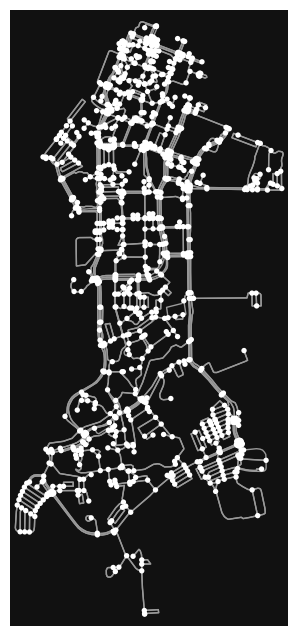

In [3]:
import osmnx

graph = osmnx.graph_from_place("Northern Arizona University, Flagstaff, Arizona, USA")
osmnx.plot_graph(graph);

Yes, this looks like what I would expect. The street network of Northern Arizona University shows a dense grid of roads and paths in the main campus area (upper portion), with more sparse and winding roads in the southern portion which corresponds to the more mountainous and forested areas around campus. The overall north-south elongated shape matches the known layout of NAU's campus.

12. Run the following cell to read in the San Diego DEM data. Notice that this code uses the rioxarray package, while the book used xarray. rioxarray has taken over from xarray for handling spatial rasters since it is a combination of:
    - RasterIO package ("rio"), which specializes in reading/writing and analysis of spatial rasters
    - xarray package, which specializes in working with labeled multidimensional arrays

    <br>    

    After running the cell
    - Read in the San Diego neighborhoods data from the textbook
    - Run `zonal_stats` on the data
    - Print the `head()` for the `zonal_stats` DataFrame
    - What do the rows in this DataFrame represent?

In [2]:
import rioxarray as rx
dem = rx.open_rasterio('../gds_book/data/nasadem/nasadem_sd.tif').sel(band=1)

In [3]:
import pandas as pd
from rasterstats import zonal_stats

sd_tracts = gpd.read_file('../gds_book/data/sandiego/sandiego_tracts.gpkg')

elevations = zonal_stats(
    sd_tracts.to_crs(dem.rio.crs),
    '../gds_book/data/nasadem/nasadem_sd.tif'
)
elevations = pd.DataFrame(elevations)
elevations.head()

,min,max,mean,count
0,-12.0,18.0,3.538397,3594
1,-2.0,94.0,35.616395,5709
2,-5.0,121.0,48.742630,10922
3,31.0,149.0,91.358777,4415
4,-32.0,965.0,184.284941,701973


Each row in this DataFrame represents one **San Diego census tract** (neighborhood). The columns show the zonal statistics computed from the DEM raster for that tract: the minimum elevation, maximum elevation, mean elevation, and count of raster pixels that fall within the tract's boundaries.

13. Analyze elevations.

    Write code to extract the following for San Diego neighborhoods.
    
    - a. Report the highest average elevation from all the neighborhoods.
    - b. Report the highest single point from all the neighborhoods.
    - c. Report the the largest elevation change for any neighborhood.   

    Is (a) or (b) larger? Does this make sense? Why?     

In [4]:
# a. Highest average elevation
print("a. Highest average elevation:", elevations['mean'].max().round(2))

# b. Highest single point (max elevation across all neighborhoods)
print("b. Highest single point:", elevations['max'].max())

# c. Largest elevation change (max - min) for any neighborhood
elevations['range'] = elevations['max'] - elevations['min']
print("c. Largest elevation change:", elevations['range'].max())

a. Highest average elevation: 1136.94
b. Highest single point: 1983.0
c. Largest elevation change: 1904.0


The highest single point (b = 1,983 meters) is larger than the highest average elevation (a = 1,136.94 meters). This makes sense because the average elevation of any neighborhood is computed across all the pixels within its boundary. Even in the highest-elevation neighborhood, there will be lower pixels that bring the average down. A single maximum point will always be at least as high as (and typically higher than) the mean of the area it belongs to.

14. Wildfires data    

    > This data publication contains a spatial database of wildfires that occurred in the United States from 1992 to 2015. It is... originally generated to support the national Fire Program Analysis (FPA) system. The wildfire records were acquired from the reporting systems of federal, state, and local fire organizations... The data were transformed to conform, when possible, to the data standards of the National Wildfire Coordinating Group (NWCG)... The resulting product, referred to as the Fire Program Analysis fire-occurrence database (FPA FOD), includes 1.88 million geo-referenced wildfire records, representing a total of 140 million acres burned during the 24-year period.

    https://www.kaggle.com/datasets/rtatman/188-million-us-wildfires

    - Read in `GSP538/exercises/data/fpa_az_ca_fires.csv` as a Pandas DataFrame, convert it to a GeoDataFrame and plot a map of the points. This file contains the Arizona and California wildfires from a larger dataset.
    - What are the spatial units of these data?

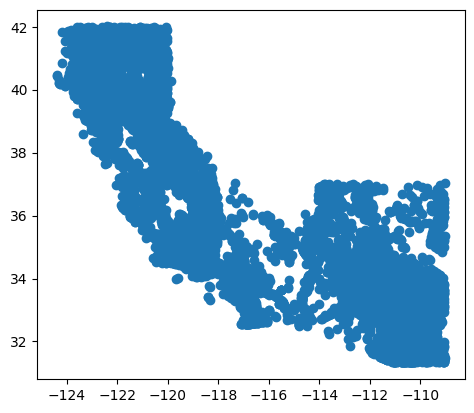

In [5]:
fires = pd.read_csv('data/fpa_az_ca_fires.csv')

pt_geoms = gpd.points_from_xy(x=fires["LONGITUDE"],
                              y=fires["LATITUDE"],
                              crs="EPSG:4326")
fires = gpd.GeoDataFrame(fires, geometry=pt_geoms)
fires.plot();

The spatial units of these data are **latitude and longitude in degrees** (WGS 84 / EPSG:4326). The x-axis shows longitude (roughly −124° to −109°) and the y-axis shows latitude (roughly 31° to 42°), corresponding to the geographic extent of Arizona and California. Each point represents one individual wildfire event.

15. Large fires.
    - Use the contextily package to plot wildfires over 10,000 acres in size on Esri's NatGeoWorldMap basemap.
    - Based on visual inspection, comment briefly on the difference between the spatial distribution of all fires (previous question) and "large" fires in this question.

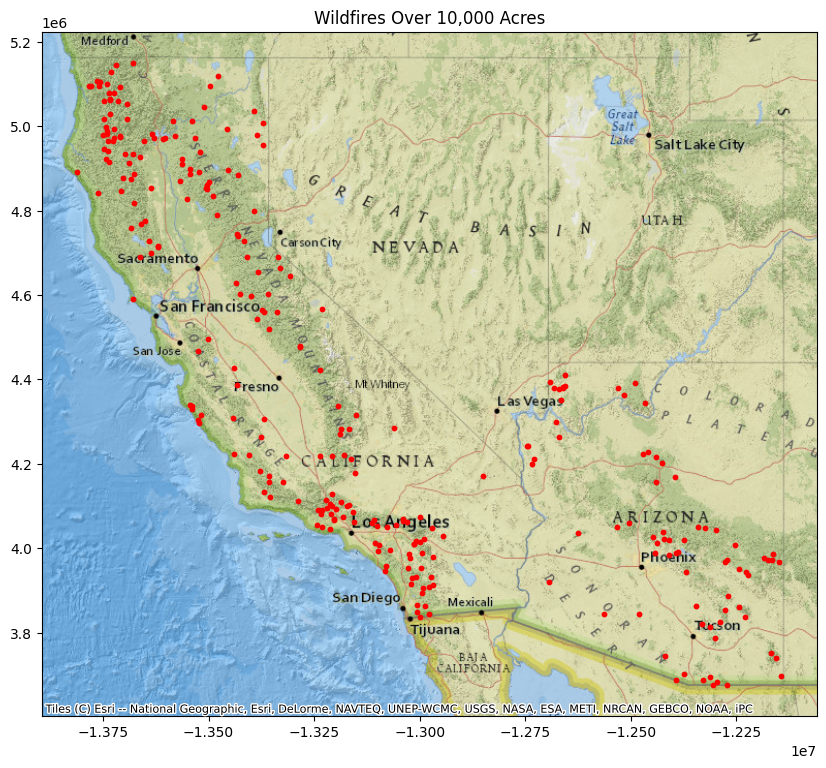

In [6]:
import contextily as cx
import matplotlib.pyplot as plt

large_fires = fires.loc[fires['FIRE_SIZE'] > 10000]
large_fires_wm = large_fires.to_crs(epsg=3857)

ax = large_fires_wm.plot(figsize=(10, 10), color='red', markersize=10)
cx.add_basemap(ax, source=cx.providers.Esri.NatGeoWorldMap)
ax.set_title('Wildfires Over 10,000 Acres')
plt.show()

The spatial distribution of large fires (>10,000 acres) differs noticeably from the distribution of all fires. While all fires blanket much of California and Arizona densely, the large fires are much more sparse and tend to cluster in Northern California's forested and mountainous regions and in the desert/grassland areas of central and southern Arizona. Urban and agricultural areas (like the Central Valley, Los Angeles basin, and the Phoenix metro area) show very few large fires despite having many small fire events recorded. This suggests that while fires occur everywhere, the ones that grow to large size tend to happen in wildland areas with continuous fuels and lower human intervention.

16. Raster version.
    - Convert the wildfire data to a raster using Datashader, and plot the raster.
      - Make sure the pixels are not so small that they look like points
      - Include a colorbar showing the values (note that this is the default as shown in the book)
      - Note: just plot the raster, not the points
      - Note: you are using all the fires, not a subset of large fires
    - What is the value of this visual representation of wildfires versus the point version in the previous questions?

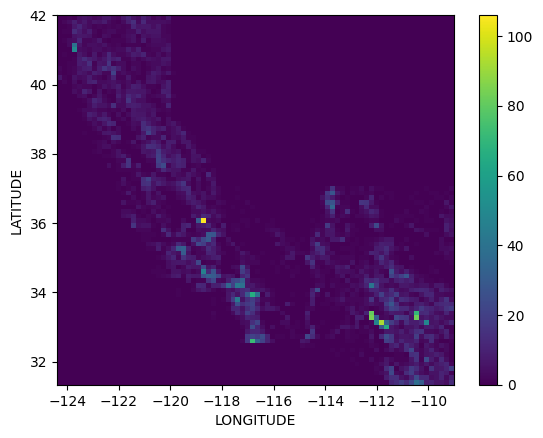

In [7]:
import datashader

cvs = datashader.Canvas(plot_width=80, plot_height=80)
grid = cvs.points(fires, x="LONGITUDE", y="LATITUDE")
grid.plot()

The raster representation reveals **density patterns** that are invisible in the point map. In the point map, densely overlapping fire locations create a solid mass of blue dots, making it impossible to distinguish between areas with 10 fires and areas with 100 fires. The raster version aggregates point counts into grid cells and uses a colorbar to show the count per cell, revealing fire "hotspots" — particularly around the Los Angeles area, the Phoenix/Tucson metro areas, and parts of Northern California. This quantitative visualization is more informative than the qualitative point cloud for understanding where fires are most concentrated.

17. Subset the raster you created in the previous question to just those cells greater than zero.
    - Make a new plot.
    - Briefly explain why there were so many zero values in the original raster. (Hint: look at the entire map from the previous question, then look at this map; notice that there is a huge number of zero cells; as to "why", leverage your knowledge about rasters from other courses.)

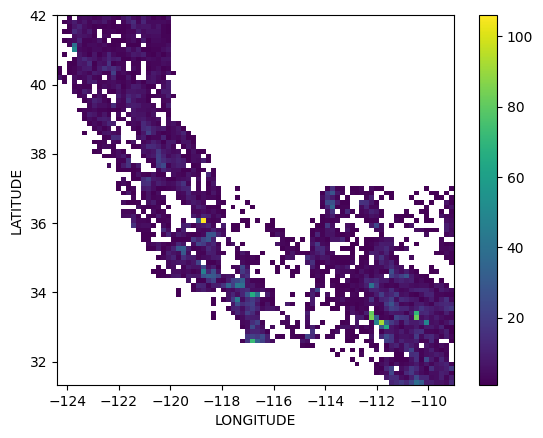

In [8]:
grid.where(grid > 0).plot()

There are so many zero-valued cells because a raster grid must cover a rectangular bounding box. The data extent spans from the northwest corner of California to the southeast corner of Arizona, and the raster fills the entire rectangular region between those extremes. However, the actual land areas of California and Arizona form a diagonal band across this rectangle. All the cells that fall outside the states — in the ocean to the west, in Nevada/Utah to the north, and in Mexico to the south — have no fire data and are recorded as zero. This is a fundamental property of raster data: the grid is always rectangular, even when the phenomenon it represents is not, resulting in many empty cells in the corners and edges.

18. Create a similar map as the one above using the `histplot` function from Seaborn to create a two-dimensional histogram.
    - Note: you have not seen two-dimensional histograms yet in this course, so you may need to Google how to do it. It is a one-line command to build the plot.
    - Note: be sure to include the colorbar like the map above did.
    - For fun: get the color map and cell size to match too.

<Axes: xlabel='LONGITUDE', ylabel='LATITUDE'>

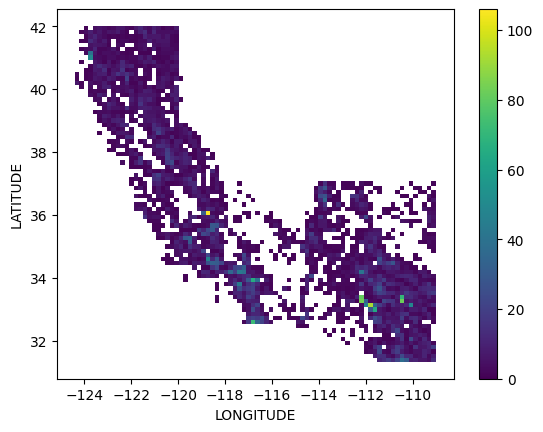

In [9]:
import seaborn as sns

sns.histplot(x=fires['LONGITUDE'], y=fires['LATITUDE'], bins=80, cbar=True, cmap='viridis')

For fun: GeoPandas has a pretty cool interactive mapping feature. Check out the `explore()` method of your fires GeoDataFrame. If your GeoDataFrame is named `fires` then it'll be `fires.explore()`. Notice that you can zoom and pan, and mouse over a point to view the attributes.

You should get a map of blue points over a tan colored basemap with the states labeled. If you don't get this:
- Click Help > Toggle Developer Tools 
- Close the panel that opens on the right side of VS Code